#  Normality Test <hr style="border:2.5px solid #126782"></hr>

<b>Byron Mojica</b>
<br>Computer Engineering Technology

In [376]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [377]:
df = pd.read_csv(r"DATASET\SOCR-HeightWeight.csv", 
                 delimiter=",", 
                 index_col="Index") # Uses the 1st column as index
df.head()

,Height(Inches),Weight(Pounds)
Index,,
1,65.78331,112.9925
2,71.51521,136.4873
3,69.39874,153.0269
4,68.21660,142.3354
5,67.78781,144.2971


In [378]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 1 to 500
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Height(Inches)  500 non-null    float64
 1   Weight(Pounds)  500 non-null    float64
dtypes: float64(2)
memory usage: 11.7 KB


In [379]:
# summary of statistics
df.describe()

,Height(Inches),Weight(Pounds)
count,500.000000,500.000000
mean,68.011371,127.216975
std,1.904719,11.900698
min,62.016660,84.359800
25%,66.699150,119.485000
50%,68.022415,127.373800
75%,69.259142,135.005275
max,73.901070,168.229000


# Data Cleaning

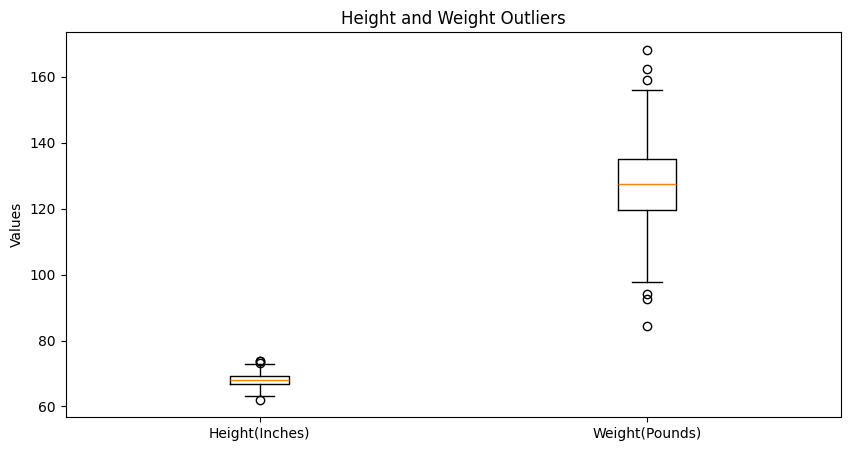

In [380]:
# check for outliers
plt.figure(figsize=(10,5))
plt.boxplot(df[['Height(Inches)', 'Weight(Pounds)']],
            tick_labels=df.columns)
plt.title('Height and Weight Outliers')
plt.ylabel('Values')
#plt.xticks(rotation=45)
plt.show()

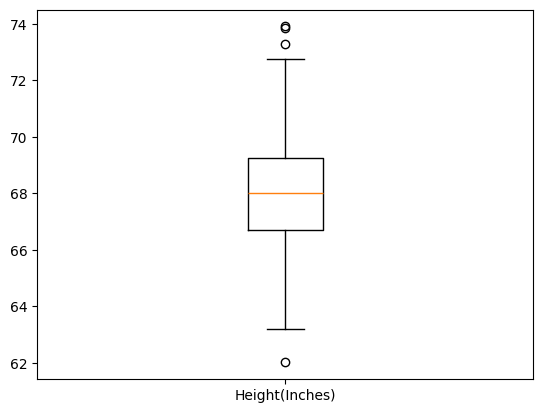

In [381]:
# Height
plt.boxplot(df['Height(Inches)'],tick_labels=['Height(Inches)'])
plt.show()

In [382]:
# removing 3-sigma outliers
z_h = stats.zscore(df['Height(Inches)'])
h_outliers = (z_h<-3)|(z_h>3)
df = df[~h_outliers]

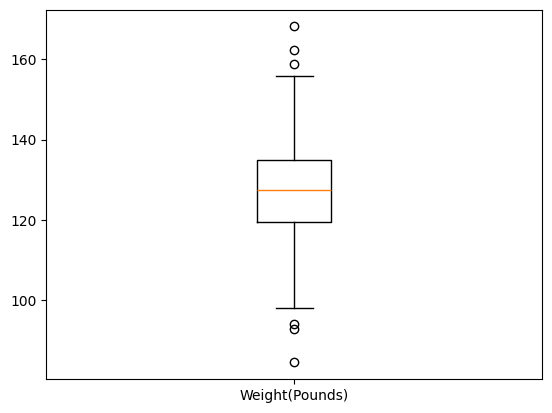

In [383]:
plt.boxplot(df['Weight(Pounds)'],tick_labels=['Weight(Pounds)'])
plt.show()

In [384]:
# wind
# removing 3-sigma outliers
z_w = stats.zscore(df['Weight(Pounds)'])
wind_outliers = (z_w<-3)|(z_w>3)
df = df[~wind_outliers]

In [385]:
# load dataset
df = pd.read_csv(r"DATASET/SOCR-HeightWeight.csv",
                 delimiter=",")
df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
495,496,66.82802,142.1577
496,497,69.09424,127.1436
497,498,66.81425,122.3353
498,499,67.13183,112.6659


In [386]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           500 non-null    int64  
 1   Height(Inches)  500 non-null    float64
 2   Weight(Pounds)  500 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [387]:
# summary of statistics
df.describe()

,Index,Height(Inches),Weight(Pounds)
count,500.000000,500.000000,500.000000
mean,250.500000,68.011371,127.216975
std,144.481833,1.904719,11.900698
min,1.000000,62.016660,84.359800
25%,125.750000,66.699150,119.485000
50%,250.500000,68.022415,127.373800
75%,375.250000,69.259142,135.005275
max,500.000000,73.901070,168.229000


# 2-Sample t-Test

In [388]:
df[['Height(Inches)','Weight(Pounds)']].describe()

,Height(Inches),Weight(Pounds)
count,500.000000,500.000000
mean,68.011371,127.216975
std,1.904719,11.900698
min,62.016660,84.359800
25%,66.699150,119.485000
50%,68.022415,127.373800
75%,69.259142,135.005275
max,73.901070,168.229000


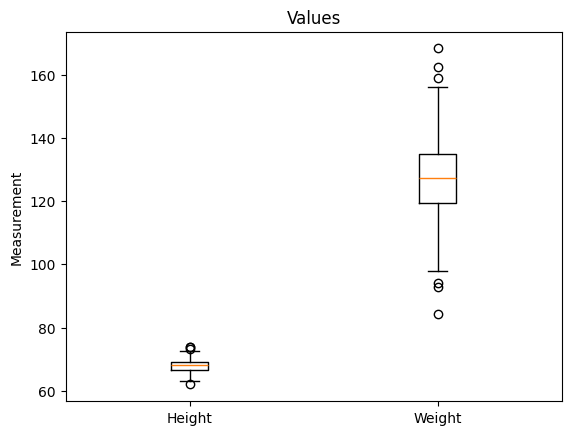

In [389]:
# check for outliers
plt.boxplot(df[['Height(Inches)','Weight(Pounds)']],tick_labels=['Height','Weight'])
plt.title("Values")
plt.ylabel('Measurement')
plt.show()

In [390]:
# shapiro-wilk normality test
print("Height")
w_stat, p_value = stats.shapiro(df['Height(Inches)'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nWeight:")
w_stat, p_value = stats.shapiro(df['Weight(Pounds)'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Height
w_stat: 0.9986
P-value: 0.9615
Normal data

Weight:
w_stat: 0.9984
P-value: 0.9368
Normal data


In [391]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_height = var_weight
Ha: var_height != var_weight
"""

var_height = df['Height(Inches)'].var(ddof=1)
var_weight = df['Weight(Pounds)'].var(ddof=1)

# F-statistic
if var_height > var_weight:
    f_stat = var_height/var_weight
else:
    f_stat = var_weight/var_height

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_height = df['Height(Inches)'].count()-1
dof_weight = df['Weight(Pounds)'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_height, dof_weight)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 39.0376
p_value = 0.0000
unequal variances


In [392]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Height = Weight
Ha: Height > Weight
"""

t_stat, p_value = stats.ttest_ind(df['Height(Inches)'],df['Weight(Pounds)'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Height is significantly greater than Weight.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between Height and Weight.")

t_stat = -109.8457
p_value = 1.0000
There is no significant difference between Height and Weight.


In [393]:
"""
left-tailed test
------------------
Ho: u_height = u_weight
Ha: u_height > u_weight
"""
    
# cohen's d
nuc_mean = df['Height(Inches)'].mean()
coal_mean = df['Weight(Pounds)'].mean()
nuc_std = df['Height(Inches)'].std(ddof=1)

d = abs((nuc_mean - coal_mean)/nuc_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['Height(Inches)'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 31.0836
Power of the test: 100.00%
